In [1]:
!pip install scikit-learn pandas numpy

In [2]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
assignments = {
    "Assignment_A": """
    Machine learning is a branch of artificial intelligence.
    It allows computers to learn from data and make predictions.
    Machine learning algorithms are used in many real world applications.
    """,

    "Assignment_B": """
    Machine learning is a branch of artificial intelligence.
    It enables computers to learn from data and make predictions.
    Machine learning algorithms are used in many real world applications.
    """,

    "Assignment_C": """
    Natural language processing is an important area of artificial intelligence.
    It helps computers understand and process human language.
    NLP is used in chatbots, translation and sentiment analysis.
    """,

    "Assignment_D": """
    Data science combines statistics, programming and machine learning.
    Data scientists analyze large datasets to discover useful patterns.
    Visualization helps communicate the results of data analysis.
    """,

    "Assignment_E": """
    Machine learning algorithms can learn patterns from historical data.
    These algorithms can be used to classify data and make predictions.
    Artificial intelligence applications use machine learning techniques.
    """
}

print("Number of assignments:", len(assignments))

Number of assignments: 5


In [4]:
for name, text in assignments.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    print(text)

Assignment_A

    Machine learning is a branch of artificial intelligence.
    It allows computers to learn from data and make predictions.
    Machine learning algorithms are used in many real world applications.
    
Assignment_B

    Machine learning is a branch of artificial intelligence.
    It enables computers to learn from data and make predictions.
    Machine learning algorithms are used in many real world applications.
    
Assignment_C

    Natural language processing is an important area of artificial intelligence.
    It helps computers understand and process human language.
    NLP is used in chatbots, translation and sentiment analysis.
    
Assignment_D

    Data science combines statistics, programming and machine learning.
    Data scientists analyze large datasets to discover useful patterns.
    Visualization helps communicate the results of data analysis.
    
Assignment_E

    Machine learning algorithms can learn patterns from historical data.
    These algorith

In [5]:
def clean_text(text):
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [6]:
cleaned_assignments = {}

for name, text in assignments.items():
    cleaned_assignments[name] = clean_text(text)

for name, text in cleaned_assignments.items():
    print(name, "->", text)

Assignment_A -> machine learning is a branch of artificial intelligence it allows computers to learn from data and make predictions machine learning algorithms are used in many real world applications
Assignment_B -> machine learning is a branch of artificial intelligence it enables computers to learn from data and make predictions machine learning algorithms are used in many real world applications
Assignment_C -> natural language processing is an important area of artificial intelligence it helps computers understand and process human language nlp is used in chatbots translation and sentiment analysis
Assignment_D -> data science combines statistics programming and machine learning data scientists analyze large datasets to discover useful patterns visualization helps communicate the results of data analysis
Assignment_E -> machine learning algorithms can learn patterns from historical data these algorithms can be used to classify data and make predictions artificial intelligence appl

In [7]:
tokenized_assignments = {}

for name, text in cleaned_assignments.items():
    tokens = text.split()
    tokenized_assignments[name] = tokens

for name, tokens in tokenized_assignments.items():
    print(name)
    print(tokens)
    print()

Assignment_A
['machine', 'learning', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'it', 'allows', 'computers', 'to', 'learn', 'from', 'data', 'and', 'make', 'predictions', 'machine', 'learning', 'algorithms', 'are', 'used', 'in', 'many', 'real', 'world', 'applications']

Assignment_B
['machine', 'learning', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'it', 'enables', 'computers', 'to', 'learn', 'from', 'data', 'and', 'make', 'predictions', 'machine', 'learning', 'algorithms', 'are', 'used', 'in', 'many', 'real', 'world', 'applications']

Assignment_C
['natural', 'language', 'processing', 'is', 'an', 'important', 'area', 'of', 'artificial', 'intelligence', 'it', 'helps', 'computers', 'understand', 'and', 'process', 'human', 'language', 'nlp', 'is', 'used', 'in', 'chatbots', 'translation', 'and', 'sentiment', 'analysis']

Assignment_D
['data', 'science', 'combines', 'statistics', 'programming', 'and', 'machine', 'learning', 'data', 'scientists', 'analyze', 'large

In [8]:
documents = []

document_names = list(tokenized_assignments.keys())

for name in document_names:
    documents.append(
        " ".join(tokenized_assignments[name])
    )

print("Documents prepared:", len(documents))

Documents prepared: 5


In [9]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (5, 63)


In [10]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of features: 63

First 30 features:
['algorithms' 'allows' 'an' 'analysis' 'analyze' 'and' 'applications'
 'are' 'area' 'artificial' 'be' 'branch' 'can' 'chatbots' 'classify'
 'combines' 'communicate' 'computers' 'data' 'datasets' 'discover'
 'enables' 'from' 'helps' 'historical' 'human' 'important' 'in'
 'intelligence' 'is']


In [11]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=document_names,
    columns=feature_names
)

tfidf_df

,algorithms,allows,an,analysis,analyze,and,applications,are,area,artificial,...,the,these,to,translation,understand,use,used,useful,visualization,world
Assignment_A,0.182881,0.273074,0.000000,0.000000,0.000000,0.130121,0.182881,0.220314,0.000000,0.153845,...,0.000000,0.000000,0.153845,0.000000,0.000000,0.000000,0.153845,0.000000,0.000000,0.220314
Assignment_B,0.182881,0.000000,0.000000,0.000000,0.000000,0.130121,0.182881,0.220314,0.000000,0.153845,...,0.000000,0.000000,0.153845,0.000000,0.000000,0.000000,0.153845,0.000000,0.000000,0.220314
Assignment_C,0.000000,0.000000,0.210262,0.169638,0.000000,0.200382,0.000000,0.000000,0.210262,0.118458,...,0.000000,0.000000,0.000000,0.210262,0.210262,0.000000,0.118458,0.000000,0.000000,0.000000
Assignment_D,0.000000,0.000000,0.000000,0.179040,0.221916,0.105744,0.000000,0.000000,0.000000,0.000000,...,0.221916,0.000000,0.125023,0.000000,0.000000,0.000000,0.000000,0.221916,0.221916,0.000000
Assignment_E,0.299557,0.000000,0.000000,0.000000,0.000000,0.106569,0.149778,0.000000,0.000000,0.125998,...,0.000000,0.223646,0.125998,0.000000,0.000000,0.223646,0.125998,0.000000,0.000000,0.000000


In [12]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (5, 5)


In [13]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=document_names,
    columns=document_names
)

similarity_df

,Assignment_A,Assignment_B,Assignment_C,Assignment_D,Assignment_E
Assignment_A,1.000000,0.925431,0.227732,0.186867,0.476986
Assignment_B,0.925431,1.000000,0.227732,0.186867,0.476986
Assignment_C,0.227732,0.227732,1.000000,0.096743,0.066131
Assignment_D,0.186867,0.186867,0.096743,1.000000,0.216854
Assignment_E,0.476986,0.476986,0.066131,0.216854,1.000000


In [14]:
similarity_percentage = similarity_df * 100

similarity_percentage.round(2)

,Assignment_A,Assignment_B,Assignment_C,Assignment_D,Assignment_E
Assignment_A,100.00,92.54,22.77,18.69,47.70
Assignment_B,92.54,100.00,22.77,18.69,47.70
Assignment_C,22.77,22.77,100.00,9.67,6.61
Assignment_D,18.69,18.69,9.67,100.00,21.69
Assignment_E,47.70,47.70,6.61,21.69,100.00


In [15]:
similarity_ab = similarity_matrix[0][1]

print(
    f"Assignment_A vs Assignment_B: "
    f"{similarity_ab * 100:.2f}%"
)

Assignment_A vs Assignment_B: 92.54%


In [16]:
threshold = 70

print("Similarity threshold:", threshold, "%")

Similarity threshold: 70 %


In [17]:
similarity_pairs = []

for i in range(len(document_names)):
    for j in range(i + 1, len(document_names)):
        
        score = similarity_matrix[i][j] * 100
        
        similarity_pairs.append({
            "Document 1": document_names[i],
            "Document 2": document_names[j],
            "Similarity (%)": score
        })

print("Total document pairs:", len(similarity_pairs))

Total document pairs: 10


In [18]:
similarity_report = pd.DataFrame(
    similarity_pairs
)

similarity_report

,Document 1,Document 2,Similarity (%)
0,Assignment_A,Assignment_B,92.543086
1,Assignment_A,Assignment_C,22.773201
2,Assignment_A,Assignment_D,18.686730
3,Assignment_A,Assignment_E,47.698605
4,Assignment_B,Assignment_C,22.773201
5,Assignment_B,Assignment_D,18.686730
6,Assignment_B,Assignment_E,47.698605
7,Assignment_C,Assignment_D,9.674322
8,Assignment_C,Assignment_E,6.613088
9,Assignment_D,Assignment_E,21.685423


In [19]:
ranked_report = similarity_report.sort_values(
    by="Similarity (%)",
    ascending=False
).reset_index(drop=True)

ranked_report

,Document 1,Document 2,Similarity (%)
0,Assignment_A,Assignment_B,92.543086
1,Assignment_B,Assignment_E,47.698605
2,Assignment_A,Assignment_E,47.698605
3,Assignment_B,Assignment_C,22.773201
4,Assignment_A,Assignment_C,22.773201
5,Assignment_D,Assignment_E,21.685423
6,Assignment_B,Assignment_D,18.686730
7,Assignment_A,Assignment_D,18.686730
8,Assignment_C,Assignment_D,9.674322
9,Assignment_C,Assignment_E,6.613088


In [20]:
ranked_report["Status"] = ranked_report[
    "Similarity (%)"
].apply(
    lambda score:
        "Possible Plagiarism"
        if score >= threshold
        else "Low Similarity"
)

ranked_report

,Document 1,Document 2,Similarity (%),Status
0,Assignment_A,Assignment_B,92.543086,Possible Plagiarism
1,Assignment_B,Assignment_E,47.698605,Low Similarity
2,Assignment_A,Assignment_E,47.698605,Low Similarity
3,Assignment_B,Assignment_C,22.773201,Low Similarity
4,Assignment_A,Assignment_C,22.773201,Low Similarity
5,Assignment_D,Assignment_E,21.685423,Low Similarity
6,Assignment_B,Assignment_D,18.686730,Low Similarity
7,Assignment_A,Assignment_D,18.686730,Low Similarity
8,Assignment_C,Assignment_D,9.674322,Low Similarity
9,Assignment_C,Assignment_E,6.613088,Low Similarity


In [21]:
suspicious_pairs = ranked_report[
    ranked_report["Similarity (%)"] >= threshold
]

print("Suspicious document pairs:")
print()

suspicious_pairs

Suspicious document pairs:



,Document 1,Document 2,Similarity (%),Status
0,Assignment_A,Assignment_B,92.543086,Possible Plagiarism


In [22]:
most_similar_pair = ranked_report.iloc[0]

print("Most Similar Pair")
print("--------------------------")

print(
    "Document 1:",
    most_similar_pair["Document 1"]
)

print(
    "Document 2:",
    most_similar_pair["Document 2"]
)

print(
    f"Similarity: "
    f"{most_similar_pair['Similarity (%)']:.2f}%"
)

print(
    "Status:",
    most_similar_pair["Status"]
)

Most Similar Pair
--------------------------
Document 1: Assignment_A
Document 2: Assignment_B
Similarity: 92.54%
Status: Possible Plagiarism


In [23]:
print("=" * 70)
print("       ASSIGNMENT SIMILARITY / PLAGIARISM REPORT")
print("=" * 70)

print(f"\nSimilarity Threshold: {threshold}%")

print("\nRanked Document Pairs:")
print("-" * 70)

for index, row in ranked_report.iterrows():
    
    print(
        f"{index + 1}. "
        f"{row['Document 1']} vs "
        f"{row['Document 2']} "
        f"→ {row['Similarity (%)']:.2f}% "
        f"→ {row['Status']}"
    )

       ASSIGNMENT SIMILARITY / PLAGIARISM REPORT

Similarity Threshold: 70%

Ranked Document Pairs:
----------------------------------------------------------------------
1. Assignment_A vs Assignment_B → 92.54% → Possible Plagiarism
2. Assignment_B vs Assignment_E → 47.70% → Low Similarity
3. Assignment_A vs Assignment_E → 47.70% → Low Similarity
4. Assignment_B vs Assignment_C → 22.77% → Low Similarity
5. Assignment_A vs Assignment_C → 22.77% → Low Similarity
6. Assignment_D vs Assignment_E → 21.69% → Low Similarity
7. Assignment_B vs Assignment_D → 18.69% → Low Similarity
8. Assignment_A vs Assignment_D → 18.69% → Low Similarity
9. Assignment_C vs Assignment_D → 9.67% → Low Similarity
10. Assignment_C vs Assignment_E → 6.61% → Low Similarity


In [25]:
import matplotlib.pyplot as plt

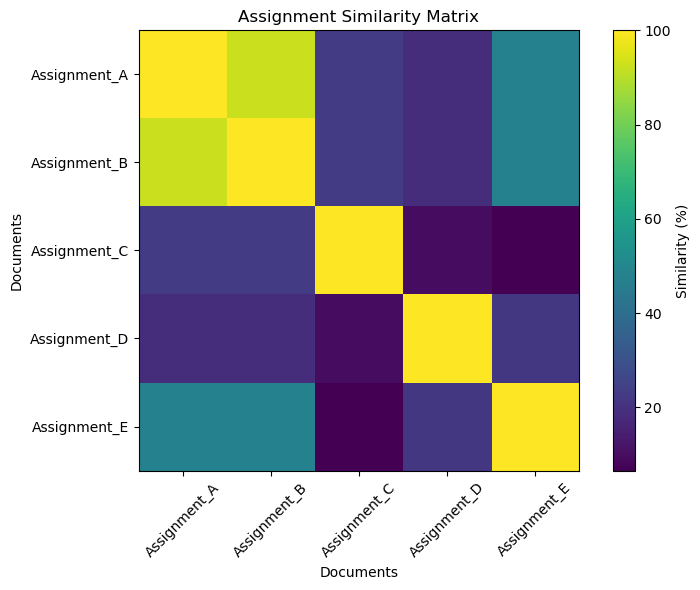

In [26]:
plt.figure(figsize=(8, 6))

plt.imshow(
    similarity_percentage,
    interpolation="nearest"
)

plt.colorbar(label="Similarity (%)")

plt.xticks(
    range(len(document_names)),
    document_names,
    rotation=45
)

plt.yticks(
    range(len(document_names)),
    document_names
)

plt.title("Assignment Similarity Matrix")

plt.xlabel("Documents")
plt.ylabel("Documents")

plt.tight_layout()

plt.show()

In [28]:
cleaned_assignments = {}

for name, text in assignments.items():
    cleaned_assignments[name] = clean_text(text)

print("All assignments cleaned successfully.")

All assignments cleaned successfully.


In [29]:
tokenized_assignments = {}

for name, text in cleaned_assignments.items():
    tokenized_assignments[name] = text.split()

print("All assignments tokenized successfully.")

All assignments tokenized successfully.


In [30]:
document_names = list(tokenized_assignments.keys())

documents = [
    " ".join(tokenized_assignments[name])
    for name in document_names
]

print("Documents:", document_names)

Documents: ['Assignment_A', 'Assignment_B', 'Assignment_C', 'Assignment_D', 'Assignment_E']


In [31]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (5, 63)


In [32]:
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_percentage = pd.DataFrame(
    similarity_matrix * 100,
    index=document_names,
    columns=document_names
)

similarity_percentage.round(2)

,Assignment_A,Assignment_B,Assignment_C,Assignment_D,Assignment_E
Assignment_A,100.00,92.54,22.77,18.69,47.70
Assignment_B,92.54,100.00,22.77,18.69,47.70
Assignment_C,22.77,22.77,100.00,9.67,6.61
Assignment_D,18.69,18.69,9.67,100.00,21.69
Assignment_E,47.70,47.70,6.61,21.69,100.00


In [33]:
similarity_pairs = []

for i in range(len(document_names)):
    for j in range(i + 1, len(document_names)):

        score = similarity_matrix[i][j] * 100

        similarity_pairs.append({
            "Document 1": document_names[i],
            "Document 2": document_names[j],
            "Similarity (%)": score
        })

similarity_report = pd.DataFrame(similarity_pairs)

ranked_report = similarity_report.sort_values(
    by="Similarity (%)",
    ascending=False
).reset_index(drop=True)

ranked_report

,Document 1,Document 2,Similarity (%)
0,Assignment_A,Assignment_B,92.543086
1,Assignment_B,Assignment_E,47.698605
2,Assignment_A,Assignment_E,47.698605
3,Assignment_B,Assignment_C,22.773201
4,Assignment_A,Assignment_C,22.773201
5,Assignment_D,Assignment_E,21.685423
6,Assignment_B,Assignment_D,18.686730
7,Assignment_A,Assignment_D,18.686730
8,Assignment_C,Assignment_D,9.674322
9,Assignment_C,Assignment_E,6.613088


In [34]:
threshold = 70

ranked_report["Status"] = ranked_report[
    "Similarity (%)"
].apply(
    lambda score:
        "Possible Plagiarism"
        if score >= threshold
        else "Low Similarity"
)

ranked_report

,Document 1,Document 2,Similarity (%),Status
0,Assignment_A,Assignment_B,92.543086,Possible Plagiarism
1,Assignment_B,Assignment_E,47.698605,Low Similarity
2,Assignment_A,Assignment_E,47.698605,Low Similarity
3,Assignment_B,Assignment_C,22.773201,Low Similarity
4,Assignment_A,Assignment_C,22.773201,Low Similarity
5,Assignment_D,Assignment_E,21.685423,Low Similarity
6,Assignment_B,Assignment_D,18.686730,Low Similarity
7,Assignment_A,Assignment_D,18.686730,Low Similarity
8,Assignment_C,Assignment_D,9.674322,Low Similarity
9,Assignment_C,Assignment_E,6.613088,Low Similarity


In [35]:
suspicious_pairs = ranked_report[
    ranked_report["Similarity (%)"] >= threshold
]

print("=" * 60)
print("SUSPICIOUS DOCUMENT PAIRS")
print("=" * 60)

if suspicious_pairs.empty:
    print("No suspicious pairs found.")
else:
    for _, row in suspicious_pairs.iterrows():
        print(
            f"{row['Document 1']} vs "
            f"{row['Document 2']} → "
            f"{row['Similarity (%)']:.2f}%"
        )

SUSPICIOUS DOCUMENT PAIRS
Assignment_A vs Assignment_B → 92.54%


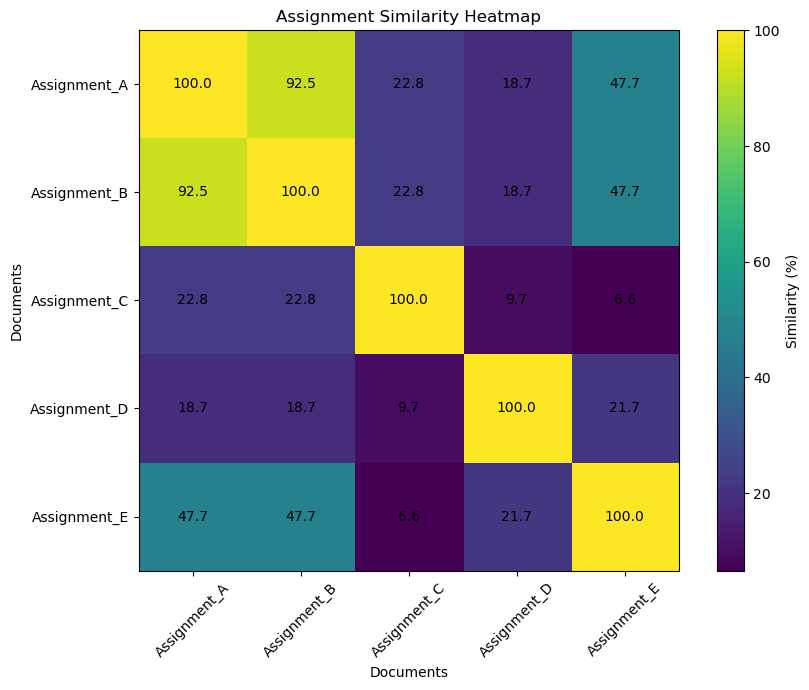

In [36]:
plt.figure(figsize=(9, 7))

plt.imshow(
    similarity_percentage,
    interpolation="nearest"
)

plt.colorbar(label="Similarity (%)")

plt.xticks(
    range(len(document_names)),
    document_names,
    rotation=45
)

plt.yticks(
    range(len(document_names)),
    document_names
)

for i in range(len(document_names)):
    for j in range(len(document_names)):
        plt.text(
            j,
            i,
            f"{similarity_percentage.iloc[i, j]:.1f}",
            ha="center",
            va="center"
        )

plt.title("Assignment Similarity Heatmap")
plt.xlabel("Documents")
plt.ylabel("Documents")

plt.tight_layout()
plt.show()

In [37]:
ranked_report.to_csv(
    "final_assignment_similarity_report.csv",
    index=False
)

print("Final report saved successfully!")

Final report saved successfully!
